# Results summary of reproducing *A Random Forest approach to identify metrics that best predict match outcome and player ranking in the esport Rocket League (Smithies et al.)*

## 1. Aim of the Reproduction
The purpose of this study was to use Random Forest models to identify in-match metrics that predicted match outcome (called PI's) and in-game player rank (called RI's).  The goal of the study was to reproduce the R workflow in python, which included:
- rf classification & OOB Permutation Importance for Rank Indicators
- multicolliniarity handling
- ntree optimization
- rfPermute-like permutation importance
- permutation based p-values
- rf regression
- various visualizations


## 2. Paper workflow


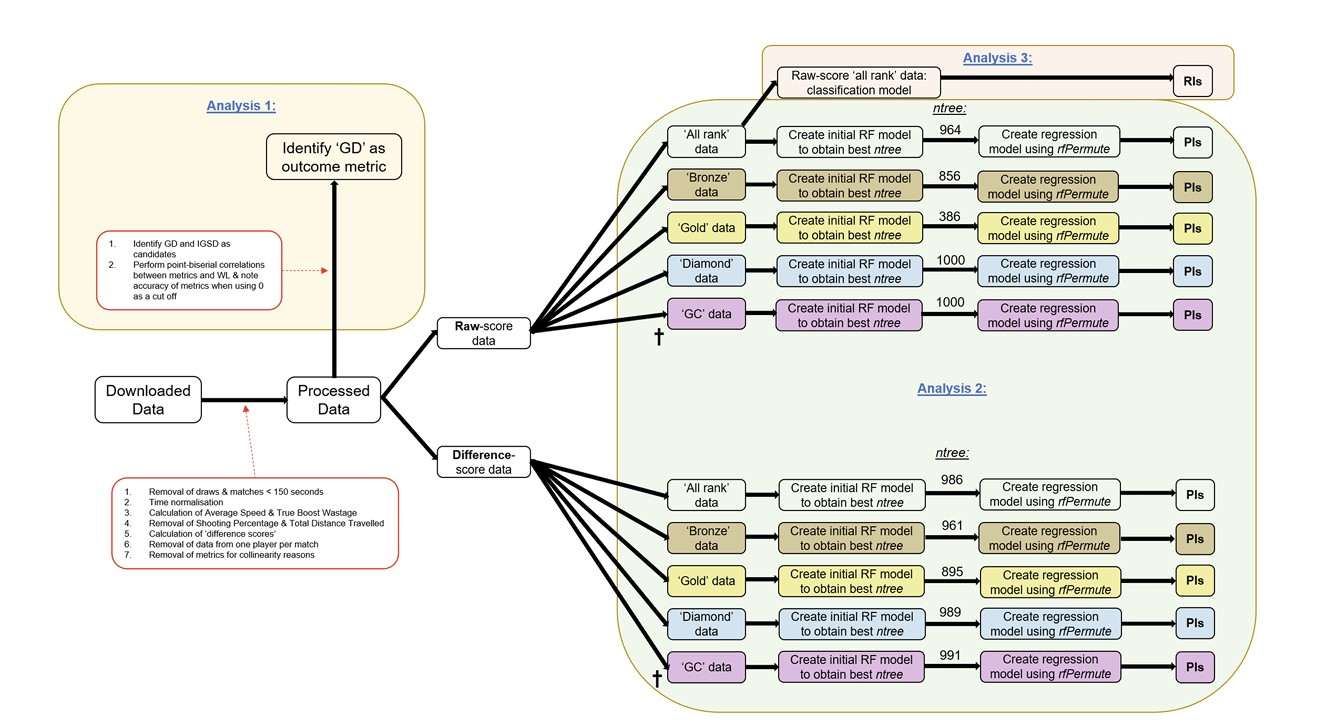

In [3]:
from IPython.display import Image, display
import base64
from IPython.display import HTML
display(Image(filename="../data_files/Workflow_chart.jpg"))

## 3. QR decomposition % ntree optimization

In the paper only average speed within the model with GC matches only was identified as multicollinear and was subsequently removed from further analyses. During our reproduction we did identify any issues with multicollinearity. 

As for the optimal ntree, we had small differences with the exception of raw_allranks and raw_gold where the difference is quite noticable. For fitting we decided to use the ntree numbers reported in the paper.


In [1]:
import pandas as pd

ntree_summary = pd.read_csv("../outputs/ntree_optimization_summary.csv")
optimal_ntrees = {
    'raw_allranks': 954,
    'raw_bronze': 856,
    'raw_gold': 380,
    'raw_diamond': 1000,
    'raw_gc': 1000,
    'diff_allranks': 986,
    'diff_bronze': 961,
    'diff_gold': 895,
    'diff_diamond': 989,
    'diff_gc': 991,
}

ntree_summary['Paper_ntree'] = ntree_summary['Dataset'].map(optimal_ntrees)
ntree_summary

,Dataset,Type,N_Features_Original,N_Features_QR,N_Dropped,Best_ntree,OOB_MSE,OOB_R2,Paper_ntree
0,raw_allranks,raw,28,28,0,855,3.611600,0.746904,954
1,raw_bronze,raw,28,28,0,845,3.908066,0.792571,856
2,raw_gold,raw,28,28,0,960,3.517468,0.743137,380
3,raw_diamond,raw,28,28,0,995,3.658571,0.725345,1000
4,raw_gc,raw,27,27,0,1000,4.052708,0.713095,1000
5,diff_allranks,diff,26,26,0,960,2.295142,0.839126,986
6,diff_bronze,diff,26,26,0,1000,2.991057,0.841057,961
7,diff_gold,diff,26,26,0,1000,2.433283,0.822310,895
8,diff_diamond,diff,26,26,0,995,2.365852,0.822392,989
9,diff_gc,diff,26,26,0,1000,2.612486,0.815053,991


## 4. Replicating rfPermute

The original paper used the R package `rfPermute` to calculate Random Forest variable importance and attach significance values to each predictor. Since `rfPermute` does not have a direct Python equivalent, we had to reproduce it manually.

First, Random Forest regression models are fitted for each dataset. Feature importance is then calculated using permutation importance, where each predictor is shuffled and the resulting increase in out-of-bag mean squared error is measured as `%IncMSE`.

We estimate feature significance by creating a null distribution through repeated permutation of the target variable. For each permutation, you refit the model and recompute permutation-based feature importance. We then compute an approximate p-value by using the proportion of null scores (fake shuffled scores) at least as large as the observed score.

The issue here is that not much of the results was actually reported. From the paper these variables were significant for raw_score PI's:

- Shots taken
- Shots conceded
- Time spent goalside of the ball
- Saves made
- Demos taken
- Demos inflicted

We achieved the same results.

In [8]:
raw_allranks_importance = pd.read_csv("../outputs/rfpermute_saved_results/per_dataset/raw_allranks_importance.csv")
raw_allranks_importance

,Dataset,Feature,PctIncMSE,PctIncMSE_SD,p_value,Significant
0,raw_allranks,shots.conceded.ag,115.226590,0.019495,0.047619,True
1,raw_allranks,percentage.behind.ball,53.539950,0.043094,0.047619,True
2,raw_allranks,shots.ag,42.904714,0.009772,0.047619,True
3,raw_allranks,saves.ag,18.955434,0.046307,0.047619,True
4,raw_allranks,percentage.defensive.third,1.925364,0.026281,0.047619,True
5,raw_allranks,percentage.offensive.third,1.071704,0.008274,0.047619,True
6,raw_allranks,demos.inflicted.ag,0.671358,0.006302,0.047619,True
7,raw_allranks,count.stolen.small.pads.ag,0.520989,0.012964,0.047619,True
8,raw_allranks,avg.boost.amount,0.454756,0.011876,0.047619,True
9,raw_allranks,percentage.supersonic.speed,0.428648,0.008135,0.047619,True


In [ ]:
summary = pd.read_csv("../outputs/rfpermute_saved_results/rfpermute_model_summary.csv")
paper_metrics = {
    "raw_bronze":    {"R2": 0.793, "MSE": 3.91},
    "raw_gold":      {"R2": 0.741, "MSE": 3.55},
    "raw_diamond":   {"R2": 0.725, "MSE": 3.66},
    "raw_gc":        {"R2": 0.713, "MSE": 4.06},
    "raw_allranks":  {"R2": 0.747, "MSE": 3.61},
    "diff_bronze":   {"R2": 0.841, "MSE": 2.99},
    "diff_gold":     {"R2": 0.823, "MSE": 2.43},
    "diff_diamond":  {"R2": 0.823, "MSE": 2.35},
    "diff_gc":       {"R2": 0.816, "MSE": 2.59},
    "diff_allranks": {"R2": 0.839, "MSE": 2.29},
}

summary["Paper_R2"] = summary["Dataset"].map(lambda d: paper_metrics[d]["R2"])
summary["Paper_MSE"] = summary["Dataset"].map(lambda d: paper_metrics[d]["MSE"])
summary["R2_Diff"] = summary["OOB_R2"] - summary["Paper_R2"]
summary["MSE_Diff"] = summary["OOB_MSE"] - summary["Paper_MSE"]
summary

,Dataset,OOB_MSE,OOB_R2,N_Significant_p05,Paper_R2,Paper_MSE,R2_Diff_OOB_minus_Paper,MSE_Diff_OOB_minus_Paper
0,raw_allranks,3.612215,0.746861,23,0.747,3.61,-0.000139,0.002215
1,raw_bronze,3.909717,0.792483,20,0.793,3.91,-0.000517,-0.000283
2,raw_gold,3.530396,0.742193,14,0.741,3.55,0.001193,-0.019604
3,raw_diamond,3.659033,0.725310,19,0.725,3.66,0.000310,-0.000967
4,raw_gc,4.052708,0.713095,14,0.713,4.06,0.000095,-0.007292
5,diff_allranks,2.296026,0.839064,15,0.839,2.29,0.000064,0.006026
6,diff_bronze,2.993299,0.840938,14,0.841,2.99,-0.000062,0.003299
7,diff_gold,2.434943,0.822189,16,0.823,2.43,-0.000811,0.004943
8,diff_diamond,2.366678,0.822330,11,0.823,2.35,-0.000670,0.016678
9,diff_gc,2.613332,0.814993,14,0.816,2.59,-0.001007,0.023332


## 5. Classification results

For OOB accuracy we used the built in functionality of RandomForestClassifier from scikit-learn. For each tree we draw n rows with replacment (bootstrap), the rows not selected were the OOB. Then for each sample, we aggregate the votes from trees which did not use it for training.

| Class   | Reproduction Accuracy | Paper Accuracy | Difference (pp) |
|---------|------------------------|----------------|-----------------|
| GC      | 73.72%                 | 73.61%         | +0.11           |
| bronze  | 69.57%                 | 69.81%         | -0.24           |
| diamond | 71.14%                 | 70.87%         | +0.27           |
| gold    | 74.77%                 | 74.65%         | +0.12           |
| global  | 72.72%                 | 72.60%         | +0.12           |

For permutation importance, the process is analogical to regression. A Random Forest classification model is fitted using OOB sampling. Feature importance is then calculated with an OOB permutation approach: for each predictor, values are shuffled in OOB samples and the drop in OOB accuracy is measured as mean decrease in accuracy. As before for significance we build a null distribution by repeatedly permutatining the y variable, in this case class lables, refit the model, recompute OOB importance and compute p-values as the proportion of null importance scores greater than or equal the observed score.


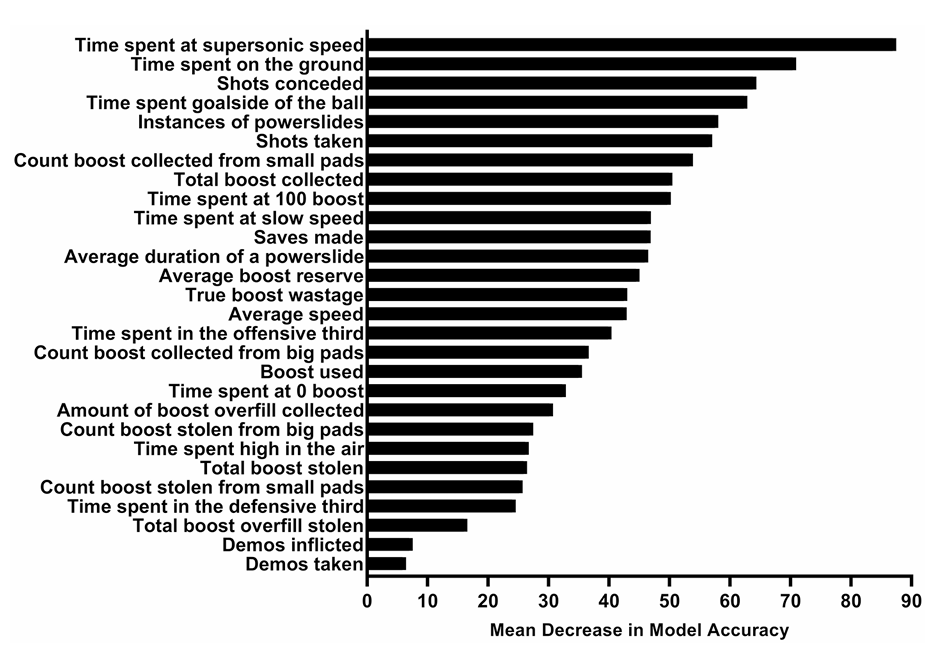
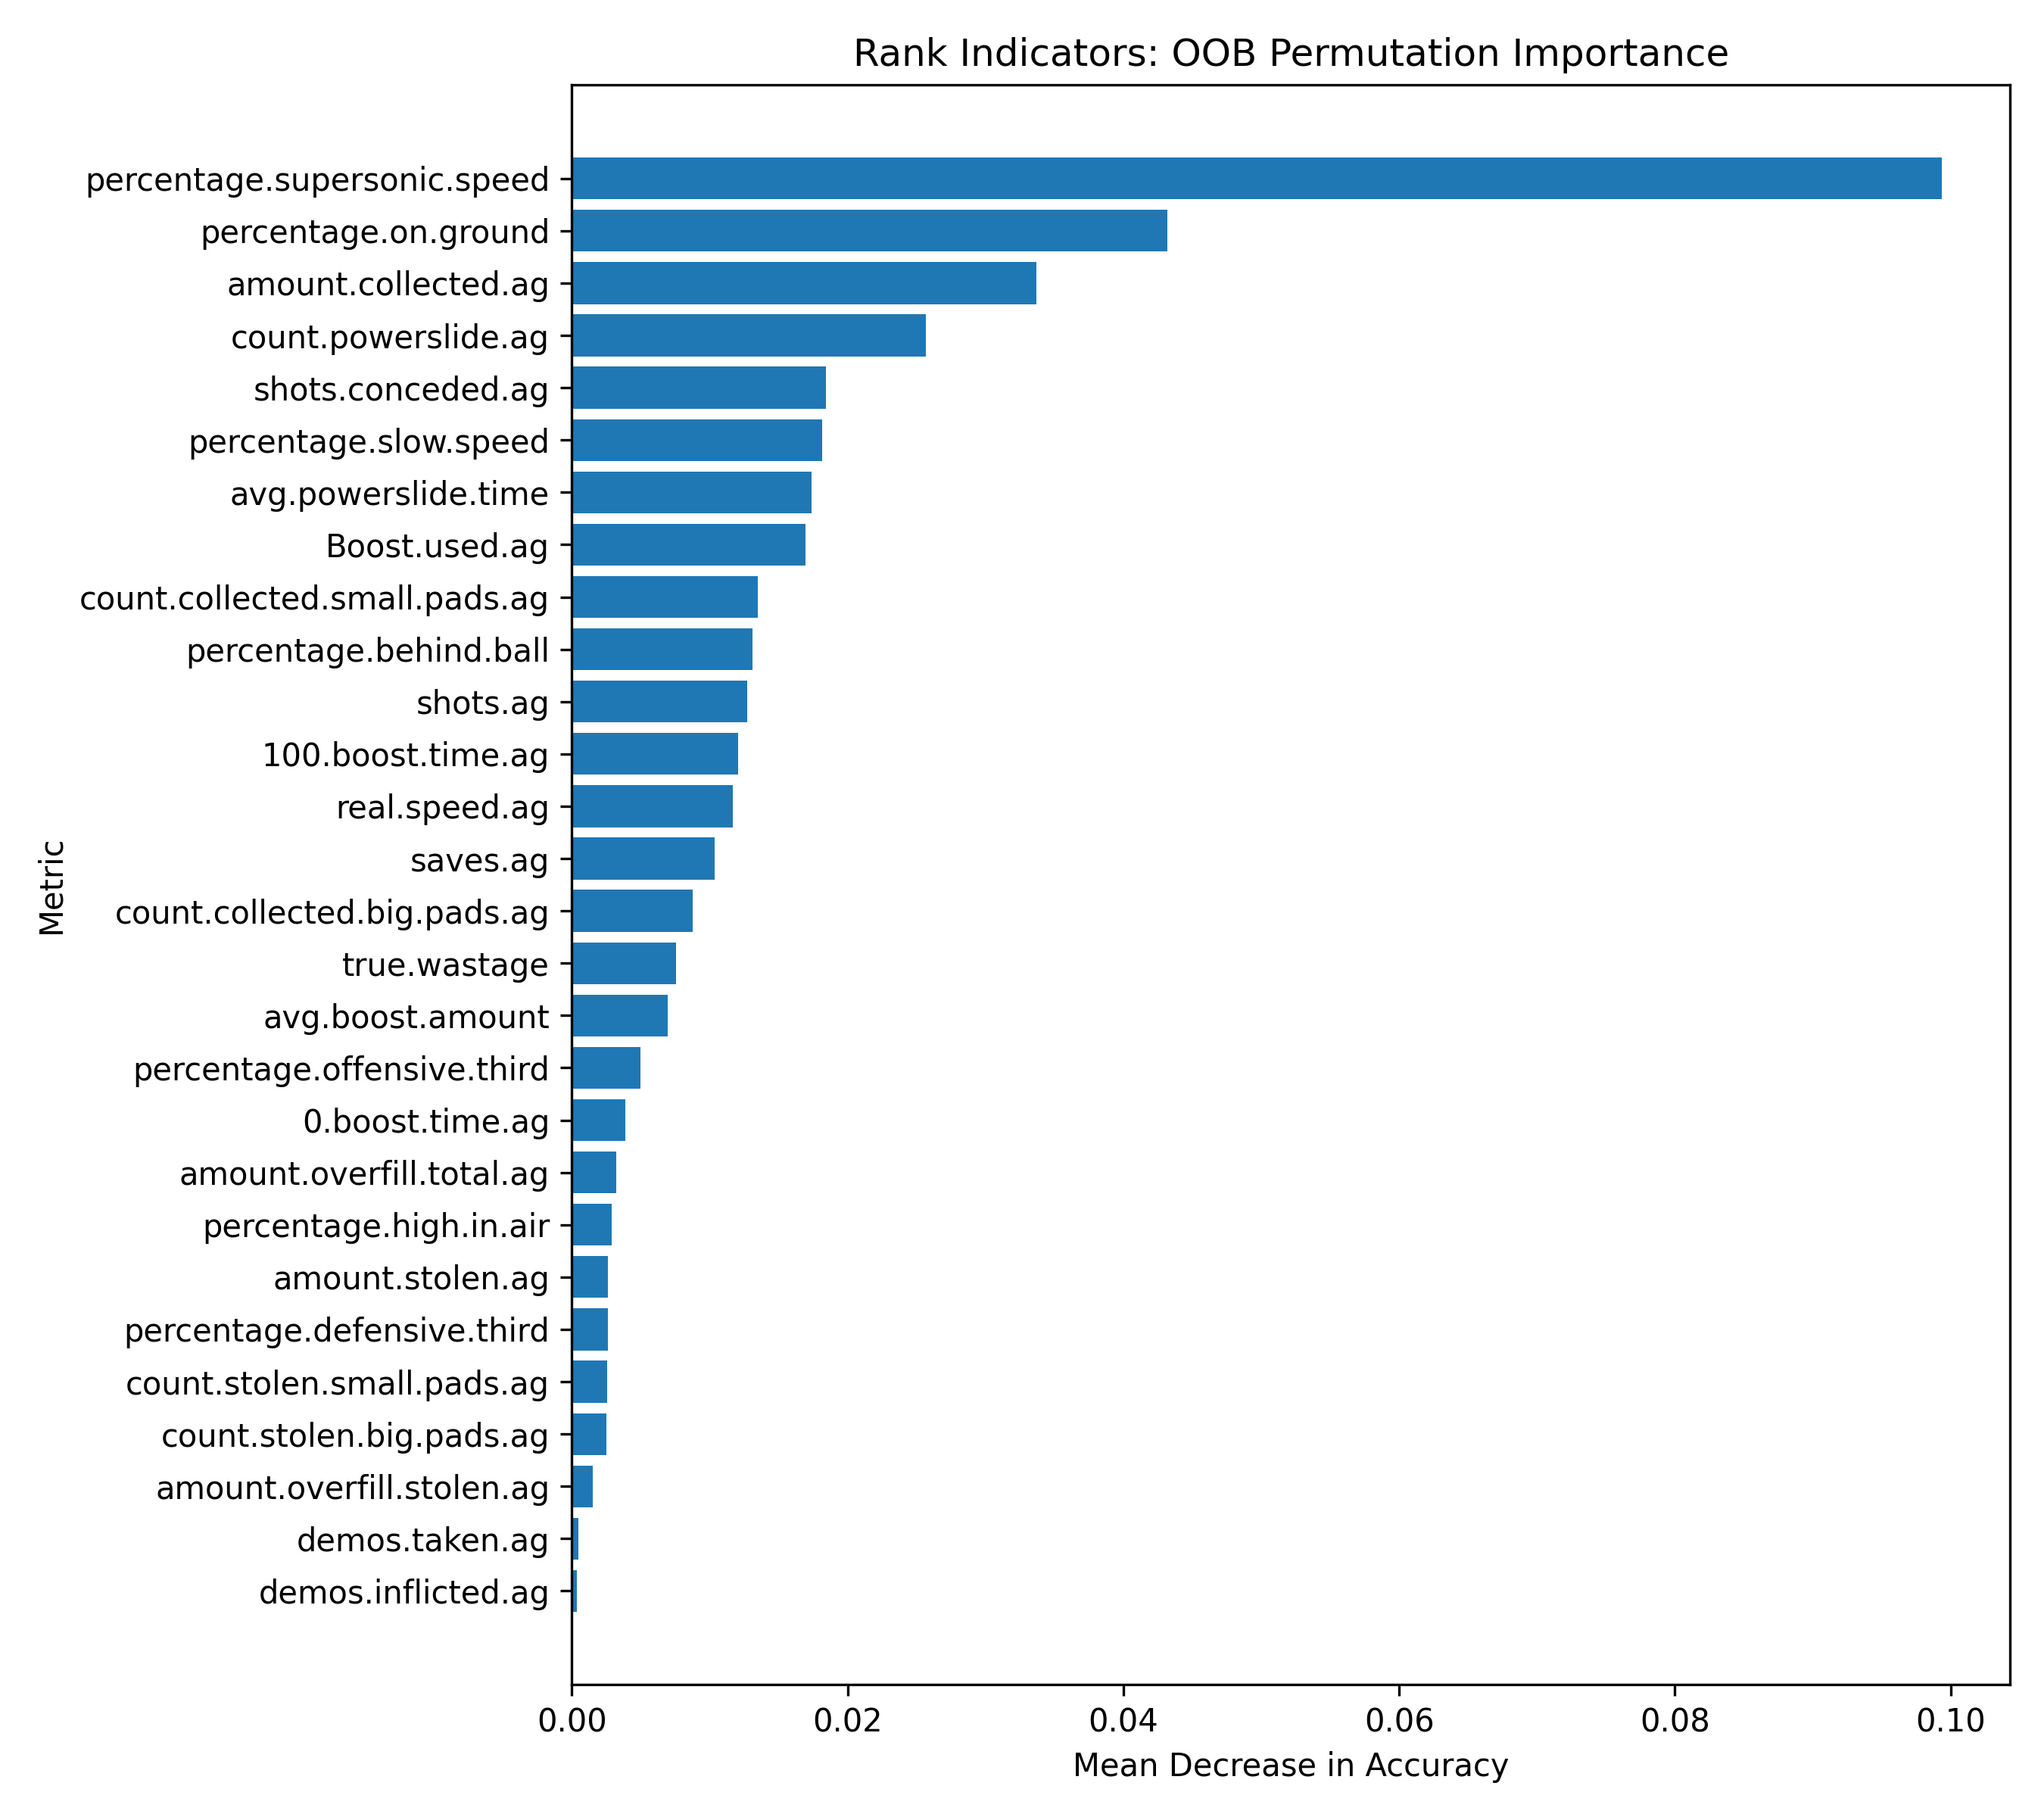

In [2]:
L

def img_to_base64(path):
    with open(path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode()
    ext = path.split(".")[-1].lower()
    mime = "image/png" if ext == "png" else "image/jpeg"
    return f"data:{mime};base64,{encoded}"

img1 = img_to_base64("../data_files/Mean_decrease_accuracy_paper.png")
img2 = img_to_base64("../outputs/RI_mean_decrease_accuracy.png")

HTML(f"""
<div style="display: flex; gap: 16px; align-items: flex-start;">
  <figure style="margin: 0; width: 50%;">
    <img src="{img1}" alt="Paper mean decrease accuracy" style="width: 100%; height: auto;" />
    <figcaption>Paper: Mean Decrease Accuracy</figcaption>
  </figure>
  <figure style="margin: 0; width: 50%;">
    <img src="{img2}" alt="Reproduction RI mean decrease accuracy" style="width: 100%; height: auto;" />
    <figcaption>Python reproduction: RI Mean Decrease Accuracy</figcaption>
  </figure>
</div>
""")